In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage,BaseMessage
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from typing import Annotated, List,TypedDict
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"  #Dont use LANGSMITH_TRACING, as it is deprecated. Use LANGCHAIN_TRACING_V2 instead.

In [2]:
@tool
def add(a:int,b:int)->int:
    """Add two numbers together and return the sum."""
    return a+b

tools=[add]
llm=ChatGroq(model="llama-3.1-8b-instant").bind_tools(tools)


In [3]:
class state(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]

In [4]:
def llm_model(state:state)->state:
    res=llm.invoke(state["messages"])
    return {"messages":[res]}

def where_to_go(state:state)->str:
    last_msg=state["messages"][-1]
    if last_msg.tool_calls:
        return "call_tool"
    return "end"

In [5]:
graph=StateGraph(state)
graph.add_node("llm",llm_model)
graph.add_edge(START,"llm")
tool_node=ToolNode(tools)
graph.add_node("tool_node",tool_node)
graph.add_conditional_edges("llm",where_to_go,
                            {
                             "call_tool":"tool_node",
                             "end":END   
                            })
graph.add_edge("tool_node","llm")
app=graph.compile()

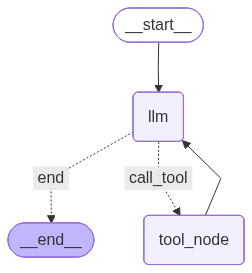

In [6]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
res=app.invoke({"messages":[" Tell me what is 5+6"]})
for msg in res['messages']:
    msg.pretty_print();

================================ Human Message =================================

 Tell me what is 5+6
================================== Ai Message ==================================
Tool Calls:
  add (83txsqgsv)
 Call ID: 83txsqgsv
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: add

11
================================== Ai Message ==================================

The result of 5+6 is 11.
